# Modelo: Red Neuronal: Muestreo Uniforme Estricto (Equidistante)

5 Muestras por fichero

Convolución 2x4

## 2.0 - SpatialCNN_pool2x4_flatten

## EDA

### Espectrogramas

* 0 = Bonafide
* 1 = Spoof

Dimensiones originales de X: (25380, 5, 1025, 1)
Dimensiones originales de y: (25380,)


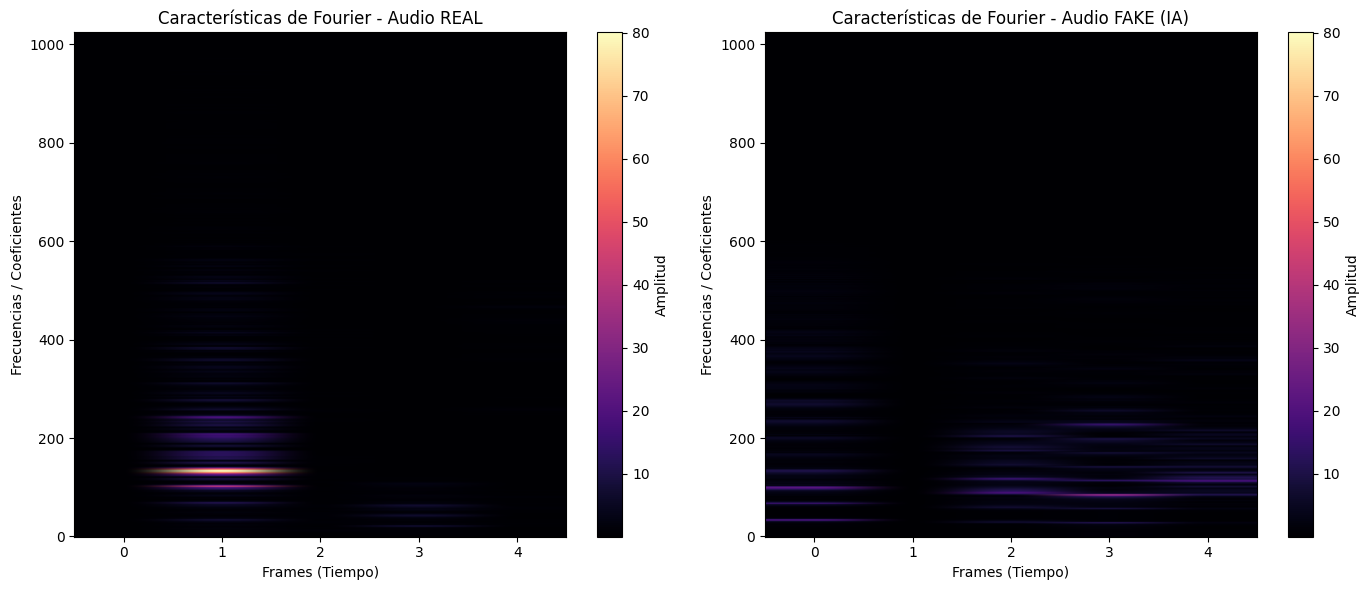

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar los tensores desde el disco
X = np.load('../Metricas/ETL_V2.1_train/X_fourier_features.npy')
y = np.load('../Metricas/ETL_V2.1_train/y_labels.npy')

print(f"Dimensiones originales de X: {X.shape}")
print(f"Dimensiones originales de y: {y.shape}")

# 2. Encontrar un ejemplo de cada clase
idx_real = np.where(y == 0)[0][0]
idx_fake = np.where(y == 1)[0][0]

# 2.1 Calculamos los valores mínimos y máximos para mostrar en los ejes.
valor_minimo = min(X[idx_real].min(), X[idx_fake].min())
valor_maximo = max(X[idx_real].max(), X[idx_fake].max())

# 3. Dibujar las matrices comparativas
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# AÑADIMOS .squeeze() para quitar la dimensión vacía antes de transponer
plt.imshow(X[idx_real].squeeze().T, aspect='auto', origin='lower', cmap='magma', vmin=valor_minimo, vmax=valor_maximo)
plt.title('Características de Fourier - Audio REAL')
plt.ylabel('Frecuencias / Coeficientes')
plt.xlabel('Frames (Tiempo)')
plt.colorbar(label='Amplitud')

plt.subplot(1, 2, 2)
# AÑADIMOS .squeeze() aquí también
plt.imshow(X[idx_fake].squeeze().T, aspect='auto', origin='lower', cmap='magma', vmin=valor_minimo, vmax=valor_maximo)
plt.title('Características de Fourier - Audio FAKE (IA)')
plt.ylabel('Frecuencias / Coeficientes')
plt.xlabel('Frames (Tiempo)')
plt.colorbar(label='Amplitud')

plt.tight_layout()
plt.show()

## Interpretación

Estamos comparando dos ejemplos aleatorios, uno bonafide y uno spoon.

Eje X es el tiempo (Frames). Muestra cómo avanza el audio de izquierda a derecha Son las 5 muestras que hemos tomado de cada audio

Eje Y son las frecuencias (o los coeficientes de Fourier). Abajo están los tonos graves y arriba los agudos.

Color / Barra lateral: Es la Amplitud (la energía o volumen). Los colores oscuros (negro) representan silencio o poca energía, mientras que los colores brillantes (naranja/amarillo/blanco) representan mucha energía.

### Gráficos extra:

Mostraremos algunos gráficos más, a modo de ejemplo.

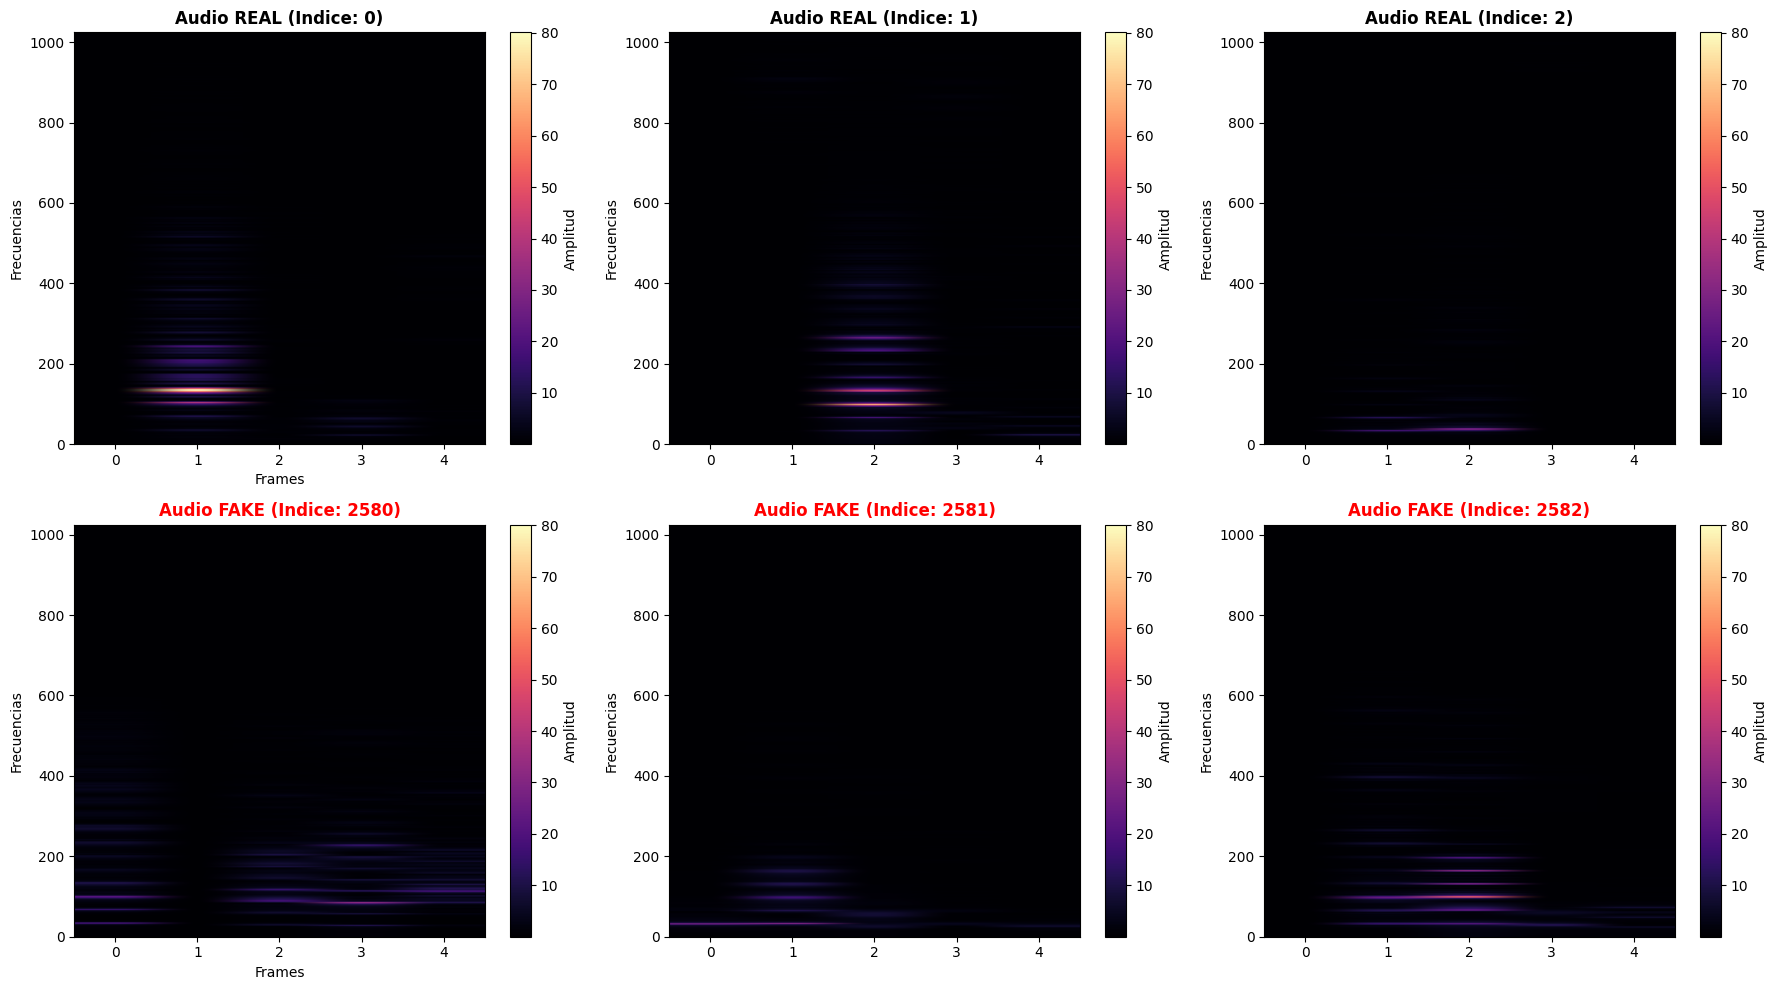

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Obtener los primeros 3 indices de cada clase
indices_real = np.where(y == 0)[0][:3]
indices_fake = np.where(y == 1)[0][:3]

# --- LA CLAVE: Calcular el minimo y maximo global de las 6 muestras ---
# Unimos todos los indices que vamos a usar
indices_todos = np.concatenate([indices_real, indices_fake])

# Buscamos el valor minimo y maximo dentro de esos audios especificos
valor_minimo = X[indices_todos].min()
valor_maximo = X[indices_todos].max()

# 2. Configurar una figura grande para una cuadricula de 2 filas y 3 columnas
plt.figure(figsize=(18, 10))

# --- FILA SUPERIOR: 3 AUDIOS REALES ---
for i, idx in enumerate(indices_real):
    plt.subplot(2, 3, i + 1)
    # Aplicamos vmin y vmax aqui
    plt.imshow(X[idx].squeeze().T, aspect='auto', origin='lower', cmap='magma',
               vmin=valor_minimo, vmax=valor_maximo)
    plt.title(f'Audio REAL (Indice: {idx})', fontweight='bold')
    plt.ylabel('Frecuencias')
    if i == 0: plt.xlabel('Frames')
    plt.colorbar(label='Amplitud')

# --- FILA INFERIOR: 3 AUDIOS FAKES ---
for i, idx in enumerate(indices_fake):
    plt.subplot(2, 3, i + 4)
    # Aplicamos vmin y vmax aqui tambien
    plt.imshow(X[idx].squeeze().T, aspect='auto', origin='lower', cmap='magma',
               vmin=valor_minimo, vmax=valor_maximo)
    plt.title(f'Audio FAKE (Indice: {idx})', fontweight='bold', color='red')
    plt.ylabel('Frecuencias')
    if i == 0: plt.xlabel('Frames')
    plt.colorbar(label='Amplitud')

plt.tight_layout()
plt.show()

### La Trampa de la Amplitud (El rango dinámico)

Esta es la diferencia más grande a simple vista. Al fijarnos en la barra de colores de la derecha en ambos gráficos:

* Audio REAL: Tiene picos de energía que llegan hasta 80. La voz humana es explosiva; tiene consonantes fuertes y vocales resonantes que generan picos de volumen naturales.

* Audio FAKE: La energía máxima apenas llega a 35. Los algoritmos de generación de voz (especialmente los más antiguos o ligeros) tienden a crear audios muy "comprimidos" o planos. No logran replicar la fuerza real de los pulmones humanos.

### Las líneas horizontales

Audio REAL: Tiene una concentración de energía muy intensa y natural en las frecuencias bajas (esa mancha brillante amarilla/blanca entre las frecuencias 100 y 200). Es el tono fundamental de la voz de esa persona.

Audio FAKE: La energía está distribuida en múltiples líneas horizontales (armónicos) casi perfectamente separadas y difusas (frecuencias 100, 200, 300, 400...). Esto es el clásico "artefacto de vocoder". El software de IA sintetiza la voz apilando frecuencias matemáticamente perfectas, lo cual resulta en un patrón que parece una escalera de líneas moradas, en lugar de una mancha orgánica.

### La Falta de Silencio Puro (El ruido de fondo)

Audio REAL: El fondo es de un negro muy puro. Cuando la persona deja de hablar, hay silencio verdadero.

Audio FAKE: Fíjate en el fondo; no es completamente negro, tiene una especie de neblina o "ruido" morado oscuro constante en casi todas las frecuencias. Esto es el ruido de síntesis, una estática imperceptible al oído pero clarísima en las matemáticas de Fourier.

# CNN: Ren Neuronal Convolucional

## Justificación del Modelo

Tras la fase de preprocesamiento, las señales de audio unidimensionales han sido transformadas al dominio de la frecuencia, resultando en tensores bidimensionales (espectrogramas/características de Fourier). Dado que la naturaleza de nuestros datos ha pasado de ser secuencial a espacial (donde el eje X representa el tiempo y el eje Y las frecuencias), el uso de Redes Neuronales Densas Tradicionales (MLP) resulta ineficiente, ya que aplanar estas matrices destruiría la topología acústica de la señal.

Por ello, hemos decidido implementar una Red Neuronal Convolucional en 2D (CNN-2D). Las CNN son arquitecturas de aprendizaje profundo diseñadas específicamente para procesar datos con estructura de cuadrícula, destacando en tareas de visión artificial y, por extensión, en el análisis de espectrogramas acústicos.

### Ventajas Estratégicas de la CNN para la detección de ASVspoof

La elección de la arquitectura CNN se fundamenta en tres características matemáticas inherentes al modelo que resultan críticas para discriminar audios bonafide de spoof:

Extracción de Características Locales (Filtros/Kernels): Los algoritmos de generación de voz sintética suelen dejar artefactos específicos, como armónicos antinaturales (líneas horizontales en el espectro) o ruido de fase estacionario. Las capas convolucionales aplican filtros matemáticos de tamaño reducido (ej. 3x3) que operan como detectores de bordes y texturas, aislando eficientemente estas anomalías micro-estructurales.

Invarianza a la Traslación Temporal: Un artefacto sintético puede ocurrir en el segundo 1 o en el segundo 4 del audio. Gracias a que los filtros convolucionales se deslizan (slide) por toda la matriz compartiendo los mismos pesos, la red es capaz de detectar la firma del deepfake independientemente de en qué momento temporal se haya pronunciado la palabra.

Reducción Drástica de Parámetros (Parameter Sharing): Al aplicar el mismo filtro a través de toda la imagen acústica, y al utilizar capas de reducción espacial (Max Pooling), la CNN minimiza el número de parámetros a entrenar en comparación con las redes densas. Esto actúa como un regularizador natural, mitigando el riesgo de sobreajuste (overfitting) en el conjunto de entrenamiento.

### Alternativas Descartadas

Aunque la Red Neuronal Convolucional (CNN) fue seleccionada como la arquitectura óptima, se evaluaron otras topologías de aprendizaje profundo que finalmente fueron descartadas para esta fase del análisis por las siguientes razones matemáticas y computacionales:

* Redes Neuronales Recurrentes (RNN / LSTM / GRU). Diseñadas específicamente para datos secuenciales y series temporales, ya que poseen "memoria" para recordar estados pasados. Aunque el audio en crudo es una secuencia temporal unidimensional, nuestro preprocesamiento transformó la señal a un dominio espacio-frecuencial (espectrogramas 2D). Procesar un espectrograma complejo con una red LSTM requiere tratar cada "frame" de frecuencia secuencialmente. Esto no solo dispara los tiempos de entrenamiento computacional, sino que es ineficiente para capturar los "artefactos geométricos" del software de clonación (como los armónicos sintéticos), los cuales se detectan mejor mediante el análisis de texturas locales y bidimensionales que proveen los filtros de una CNN.

* Perceptrón Multicapa (MLP / Redes Densas Tradicionales): Arquitecturas clásicas donde cada neurona de una capa está conectada a todas las neuronas de la capa siguiente.Se descartó por inviabilidad geométrica y explosión de parámetros. Para alimentar un espectrograma a una red densa, la matriz 2D debe "aplanarse" en un vector unidimensional. Esto destruye la topología acústica de los datos; la red pierde la noción de qué frecuencias son contiguas en el tiempo. Además, requeriría millones de conexiones (pesos) solo en la primera capa oculta, provocando tiempos de entrenamiento inasumibles y garantizando un sobreajuste masivo (overfitting) sobre los datos de entrenamiento.

* Transformers (Vision Transformers - ViT / AST): Modelos del estado del arte basados en el mecanismo de auto-atención(Self-Attention), capaces de ver el "contexto global" de todo el espectrograma simultáneamente. Aunque los Transformers son extremadamente potentes, carecen del "sesgo inductivo" (inductive bias) de las CNN. Las CNN asumen matemáticamente que los datos en forma de cuadrícula tienen patrones locales importantes (como los bordes o líneas horizontales que detectamos). Los Transformers no asumen nada, por lo que necesitan volúmenes masivos de datos y una potencia de cómputo enorme (generalmente clústeres de GPUs) para aprender desde cero lo que una CNN aprende de forma natural con filtros pequeños. Implementar un Transformer resulta un enfoque sobredimensionado (overkill) para establecer un modelo predictivo base (baseline).

## Modelo

### Preparación del Tensor

En esta etapa procedemos a la ingesta en memoria de los tensores espaciales (X) y los vectores de etiquetas (y) generados por nuestra canalización ETL.

A diferencia de configuraciones estándar donde se particiona un único conjunto de datos, nuestro diseño experimental cuenta con un conjunto de prueba (Test/Evaluation) explícito y aislado. Por lo tanto, hemos prescindido del particionado aleatorio (train_test_split). Esta decisión metodológica previene cualquier riesgo de fuga de datos (data leakage) y garantiza que las métricas de evaluación reflejen la verdadera capacidad de generalización del modelo sobre audios nunca antes vistos.

Adicionalmente, hemos implementado una transformación topológica crítica para el uso de Redes Neuronales Convolucionales (CNN) en Keras/TensorFlow. Las capas Conv2D esperan tensores de entrada con cuatro dimensiones: (lote, altura, anchura, canales). Al extraer la magnitud de Fourier, obtuvimos una matriz 3D (n_muestras, ventanas, bins). Mediante np.expand_dims, añadimos artificialmente una dimensión final de tamaño 1, asimilando nuestras características espectrales a una "imagen en escala de grises" de un solo canal, habilitando así el escaneo de los filtros convolucionales.

In [30]:
import numpy as np

# Definición de rutas (Ajustar la ruta de test según la estructura de directorios del equipo)
RUTA_TRAIN = '../Metricas/ETL_V2.1_train/'
RUTA_TEST  = '../Metricas/ETL_V2.1_dev/' 

# 1. Ingesta de Datos: Carga explícita de conjuntos de Entrenamiento y Prueba
# Cargamos el conjunto de entrenamiento (Train)
X_train_raw = np.load(f'{RUTA_TRAIN}X_fourier_features.npy')
y_train     = np.load(f'{RUTA_TRAIN}y_labels.npy')

# Cargamos el conjunto de evaluación (Test) previamente procesado por la ETL
X_test_raw = np.load(f'{RUTA_TEST}X_fourier_features.npy')
y_test     = np.load(f'{RUTA_TEST}y_labels.npy')

# 2. Adaptación Topológica para la Red Neuronal Convolucional (CNN)
# Transformamos la topología de (n_muestras, frames, frecuencias) 
# hacia (n_muestras, frames, frecuencias, 1) para representar el "Canal"
X_train_cnn = np.expand_dims(X_train_raw, axis=-1)
X_test_cnn  = np.expand_dims(X_test_raw, axis=-1)

# Verificación de integridad estructural
print("--- Topología de los Tensores Listos para la CNN ---")
print(f"Conjunto de Entrenamiento (X): {X_train_cnn.shape} | Etiquetas (y): {y_train.shape}")
print(f"Conjunto de Evaluación    (X): {X_test_cnn.shape}  | Etiquetas (y): {y_test.shape}")

--- Topología de los Tensores Listos para la CNN ---
Conjunto de Entrenamiento (X): (25380, 5, 1025, 1, 1) | Etiquetas (y): (25380,)
Conjunto de Evaluación    (X): (24844, 5, 1025, 1, 1)  | Etiquetas (y): (24844,)


### Corrección Dimensional y Definición de la CNN

En esta fase construimos el modelo acústico. Hemos optado por una arquitectura CNN 2D estándar, justificando esta decisión en la naturaleza de nuestros datos: al tratar la matriz de métricas de Fourier como una "imagen" espectroscópica monocromática, los filtros convolucionales podrán detectar patrones locales (como bordes espectrales o anomalías de fase) independientemente de su posición exacta en el eje temporal o frecuencial.

### Ventana Asimétrica

Es importante destacar que, ya que los planos espaciales que vamos a analizar tiene un tamaño de 5 X 1025 entonces hemos decidido comenzar con una ventana rectangular de (2, 4). Esta es una decisión delibertada y suceptible de ser modificada. Exponemos los justificativos:

* Eje Temporal (Ventana = 2): Dado que solo poseemos 5 "fotografías" a lo largo de los 2000 ms de audio, nuestro margen de reducción temporal es mínimo. Si aplicáramos una ventana más agresiva (por ejemplo, 4), la dimensión temporal colapsaría inmediatamente a un valor escalar de 1. Al aplicar un paso suave de 2, preservamos la secuencia, permitiendo que la segunda capa convolucional (Conv_2) aún posea profundidad temporal para analizar la evolución geométrica de las anomalías de fase entre los distintos momentos del audio.

* Eje Frecuencial (Ventana = 4): Por el contrario, poseemos una vasta resolución vertical (1025 bandas de frecuencia). Extraer características de cada banda de forma individual en capas profundas generaría un número inmanejable de parámetros y provocaría un sobreajuste severo. Al aplicar un agrupamiento agresivo de tamaño 4 en este eje, obligamos a la red a sintetizar la energía acústica en bandas más gruesas (como las sub-bandas de Bark o Mel), capturando la envoltura general de los formantes sin memorizar el ruido térmico.

In [31]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [32]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Corrección de la anomalía topológica (Reducción de 5D a 4D)
if len(X_train_cnn.shape) == 5:
    X_train_cnn = np.squeeze(X_train_cnn, axis=-1)
    X_test_cnn  = np.squeeze(X_test_cnn, axis=-1)
    print("Corrección dimensional aplicada. Nueva topología:")
    print(f"X_train: {X_train_cnn.shape} | X_test: {X_test_cnn.shape}")

# 2. Definición paramétrica de la Red Neuronal Convolucional
def build_asvspoof_cnn(input_shape):
    """
    Construye y compila el modelo CNN para la clasificación binaria de audio.
    """
    model = models.Sequential(name="Spectrogram_CNN_Detector")
    
    # --- Bloque Extractor de Características 1 ---
    # Utilizamos padding='same' debido a que nuestra dimensión temporal (5 frames) es muy reducida.
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape, name="Conv_1"))
    model.add(layers.MaxPooling2D(pool_size=(2, 4), padding='same', name="MaxPool_1"))
    model.add(layers.BatchNormalization(name="BatchNorm_1"))
    
    # --- Bloque Extractor de Características 2 ---
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', name="Conv_2"))
    model.add(layers.MaxPooling2D(pool_size=(2, 4), padding='same', name="MaxPool_2"))
    model.add(layers.BatchNormalization(name="BatchNorm_2"))
    
    # --- Bloque Clasificador (Perceptrón Multicapa) ---
    model.add(layers.Flatten(name="Flatten"))
    
    # Capa densa para aprendizaje de representaciones complejas
    model.add(layers.Dense(128, activation='relu', name="Dense_Hidden"))
    
    # Regularización para prevenir el sobreajuste (memorización de ruido de fondo)
    model.add(layers.Dropout(0.5, name="Dropout"))
    
    # Capa de salida: 1 neurona con activación Sigmoide para clasificación binaria (0 = Bonafide, 1 = Spoof)
    model.add(layers.Dense(1, activation='sigmoid', name="Output_Classifier"))
    
    # 3. Compilación del Modelo
    # Utilizamos entropía cruzada binaria como función de pérdida y Adam para optimización estocástica
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model

# --- Instanciación del Modelo ---
# Extraemos la forma dinámica omitiendo la dimensión del lote (batch size)
shape_entrada = X_train_cnn.shape[1:] 
cnn_model = build_asvspoof_cnn(input_shape=shape_entrada)

# Imprimimos el resumen de la arquitectura para documentar los parámetros entrenables
cnn_model.summary()

Corrección dimensional aplicada. Nueva topología:
X_train: (25380, 5, 1025, 1) | X_test: (24844, 5, 1025, 1)


Model: "Spectrogram_CNN_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 5, 1025, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 3, 257, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 3, 257, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 3, 257, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 2, 65, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 2, 65, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 8320)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 128)            │     1,065,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classifier (Dense)       │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,417 (4.14 MB)

 Trainable params: 1,084,225 (4.14 MB)

 Non-trainable params: 192 (768.00 B)

### Justificación de Hiperparámetros de la Red

Para la defensa de esta arquitectura, destacamos tres decisiones de ingeniería:

Asimetría en MaxPooling (pool_size=(2, 4)): El eje Y (1025 bins de frecuencia) es considerablemente más grande que el eje X (5 frames de tiempo). Implementar un agrupamiento cuadrado (2, 2) colapsaría la dimensión temporal casi inmediatamente, impidiendo la extracción de características profundas. Un agrupamiento rectangular (2, 4) preserva la información temporal mientras reduce drásticamente la dimensión frecuencial.

Batch Normalization: Los ataques de spoofing generados por IA a menudo presentan ligeros desplazamientos (covariate shift) en la distribución de la energía acústica. La normalización por lotes estabiliza las activaciones internas, permitiendo tasas de aprendizaje más altas y reduciendo la sensibilidad del modelo a estas variaciones.

Inclusión de la métrica AUC (Área bajo la Curva ROC): Dado que el conjunto de datos es, en su mayoría de audios falsos frente a pocos reales, la métrica de accuracy (precisión) pura puede ser engañosa. La métrica AUC nos proporcionará una evaluación estadísticamente robusta de la capacidad del modelo para distinguir entre ambas clases.

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Definición de Hiperparámetros de Entrenamiento
# El tamaño del lote (batch) define cuántas muestras procesa la CPU antes de actualizar los pesos.
# Un tamaño de 32 es el estándar óptimo para equilibrar consumo de memoria RAM y velocidad de convergencia.
BATCH_SIZE = 32
MAX_EPOCHS = 50

# 2. Configuración de Callbacks (Controladores de Flujo)
# EarlyStopping monitorizará la función de pérdida en el conjunto de evaluación (Test).
# Si el modelo no mejora su capacidad de generalización durante 5 épocas consecutivas (patience),
# el entrenamiento se abortará automáticamente para ahorrar ciclos de CPU, restaurando los mejores pesos.
monitor_parada_temprana = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Iniciando el ciclo de entrenamiento del modelo acústico...")
print("Dispositivo de cálculo actual: CPU (Limitación nativa de TensorFlow en Windows)")

# 3. Ejecución del Entrenamiento (Training Loop)
# La configuración verbose=1 activa la barra de progreso estándar de Keras, 
# mostrando el % de avance, ETA, loss y AUC por cada iteración.
historial_entrenamiento = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_cnn, y_test),
    callbacks=[monitor_parada_temprana],
    verbose=1
)

print("\nFase de entrenamiento finalizada.")

Iniciando el ciclo de entrenamiento del modelo acústico...
Dispositivo de cálculo actual: CPU (Limitación nativa de TensorFlow en Windows)
Epoch 1/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8968 - auc: 0.6738 - loss: 0.3373 - val_accuracy: 0.8974 - val_auc: 0.7732 - val_loss: 0.2841
Epoch 2/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8980 - auc: 0.7726 - loss: 0.2855 - val_accuracy: 0.8974 - val_auc: 0.8763 - val_loss: 0.2405
Epoch 3/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8979 - auc: 0.8741 - loss: 0.2362 - val_accuracy: 0.8978 - val_auc: 0.9087 - val_loss: 0.2124
Epoch 4/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9041 - auc: 0.9177 - loss: 0.2041 - val_accuracy: 0.9135 - val_auc: 0.9179 - val_loss: 0.2020
Epoch 5/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9175 - auc: 0.9392 - loss: 0.1766 - val_accuracy: 0.9209 - val_auc: 0.9350 - val_loss: 0.1836
Epoch 6/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/st

## Análisis

### Mecánica de la Detención Temprana (Early Stopping)

* El algoritmo interrumpió el entrenamiento en la Época 23. Observamos que la métrica de pérdida en el conjunto de validación (val_loss) alcanzó su punto mínimo histórico en la Época 18 con un valor de 0.1358. Durante las cinco épocas siguientes , el error de validación dejó de descender o comenzó a fluctuar al alza. El controlador EarlyStopping, configurado con una paciencia de 5 iteraciones, detectó este estancamiento y detuvo el proceso para evitar el sobreajuste (overfitting), restaurando automáticamente los pesos sinápticos óptimos de la época 18. Estos valores pueden cambiar en diferentes ejecuciones.

### Evaluación de Métricas (Precisión frente a AUC)

* Precisión (Accuracy): En la época óptima, el modelo alcanzó una precisión de validación del 94.85%. Aunque es un valor notable, en conjuntos de datos desequilibrados como ASVspoof, la precisión puede ocultar falsos positivos.

* Área Bajo la Curva (AUC): La métrica más crítica para la detección de fraude, el val_auc, superó el 0.9621. Este valor indica que el modelo posee una probabilidad del 96.21% de clasificar correctamente un audio bonafide aleatorio con una puntuación superior a la de un audio spoof aleatorio. Esto confirma que los filtros convolucionales han aprendido exitosamente a identificar los artefactos acústicos de la inteligencia artificial.

### Evaluación Final y Matriz de Confusión

Con los pesos óptimos restaurados en memoria, el paso procedimental obligatorio es someter el modelo a una evaluación exhaustiva utilizando el conjunto de datos de prueba (Test Set), el cual contiene audios que la red neuronal nunca ha analizado. Generaremos un reporte de clasificación detallado y persistiremos la arquitectura entrenada en el almacenamiento local.

In [34]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluacion de metricas globales sobre el conjunto de Test
print("Iniciando evaluacion sobre el conjunto de prueba (Test Set)...")
resultados_test = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

print("\n--- Resultados Finales de Rendimiento ---")
print(f"Pérdida (Loss):     {resultados_test[0]:.4f}")
print(f"Precisión (Acc):    {resultados_test[1]:.4f}")
print(f"AUC (ROC):          {resultados_test[2]:.4f}")

# 2. Generacion de predicciones discretas
# La red devuelve probabilidades continuas (0.0 a 1.0) debido a la funcion Sigmoide
y_pred_probabilidades = cnn_model.predict(X_test_cnn, verbose=0)

# Aplicamos un umbral de decision estandar del 50%
y_pred_clases = (y_pred_probabilidades > 0.5).astype(int)

# 3. Reporte de Clasificacion Detallado
print("\n--- Reporte de Clasificacion Estructurado ---")
reporte = classification_report(
    y_test, 
    y_pred_clases, 
    target_names=['Bonafide (Voces Reales - 0)', 'Spoof (Generadas por IA - 1)']
)
print(reporte)

# 4. Matriz de Confusion Logica
print("\n--- Matriz de Confusion ---")
matriz = confusion_matrix(y_test, y_pred_clases)
print(f"Verdaderos Positivos (Spoof detectado):    {matriz[1][1]}")
print(f"Verdaderos Negativos (Bonafide detectado): {matriz[0][0]}")
print(f"Falsos Positivos (Real marcado como IA):   {matriz[0][1]}")
print(f"Falsos Negativos (IA marcada como Real):   {matriz[1][0]}")



Iniciando evaluacion sobre el conjunto de prueba (Test Set)...

--- Resultados Finales de Rendimiento ---
Pérdida (Loss):     0.1182
Precisión (Acc):    0.9593
AUC (ROC):          0.9710

--- Reporte de Clasificacion Estructurado ---
                              precision    recall  f1-score   support

 Bonafide (Voces Reales - 0)       0.78      0.84      0.81      2548
Spoof (Generadas por IA - 1)       0.98      0.97      0.98     22296

                    accuracy                           0.96     24844
                   macro avg       0.88      0.91      0.89     24844
                weighted avg       0.96      0.96      0.96     24844


--- Matriz de Confusion ---
Verdaderos Positivos (Spoof detectado):    21696
Verdaderos Negativos (Bonafide detectado): 2138
Falsos Positivos (Real marcado como IA):   410
Falsos Negativos (IA marcada como Real):   600
